# 03 Survival

Session duration as a time-to-event problem, on top of `/data/work/sessions_clustered/sessions_clustered.parquet`. `event_observed=True` means the attacker hung up; `False` means the honeypot's idle timeout (~120s, from 00) cut the session instead, so the true hang-up time is unknown and only a lower bound.

Noise (`cluster == -1`, 317 sessions) is left out of every cluster-based section below, the same call as in 02.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import multivariate_logrank_test

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sessions = pd.read_parquet("/data/work/sessions_clustered/sessions_clustered.parquet")
clustered = sessions[sessions["cluster"] != -1].copy()
print(sessions.shape, "->", clustered.shape, "after dropping noise")
sessions["event_observed"].value_counts()

(22511, 40) -> (20782, 40) after dropping noise


event_observed
True     21937
False      574
Name: count, dtype: int64

## 1. Does the censoring actually matter

Fitting the real curve against a naive one that treats every session as attacker-terminated, including the timed-out ones. If they overlap, the timeout distinction was not worth the trouble in 00 and 01. If they split, it was.

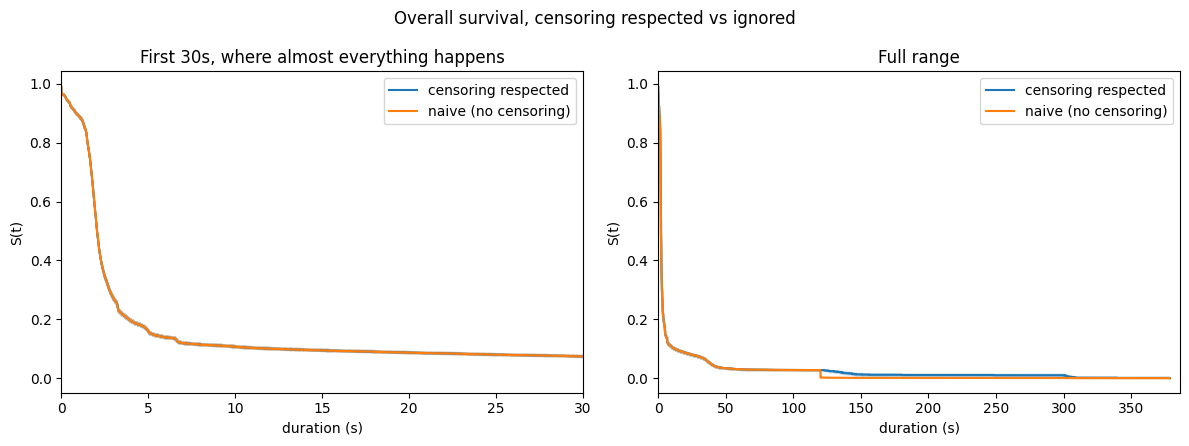

In [2]:
kmf_real = KaplanMeierFitter().fit(
    sessions["duration_sec"], sessions["event_observed"], label="censoring respected"
)
kmf_naive = KaplanMeierFitter().fit(
    sessions["duration_sec"], np.ones(len(sessions)), label="naive (no censoring)"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, xlim in zip(axes, [(0, 30), (0, sessions["duration_sec"].max() * 1.02)]):
    kmf_real.plot_survival_function(ax=ax)
    kmf_naive.plot_survival_function(ax=ax)
    ax.set_xlim(*xlim)
    ax.set_xlabel("duration (s)")
    ax.set_ylabel("S(t)")
axes[0].set_title("First 30s, where almost everything happens")
axes[1].set_title("Full range")
fig.suptitle("Overall survival, censoring respected vs ignored")
fig.tight_layout()
plt.show()

The two curves are identical below 120s, since nothing is censored before the timeout band, and split apart only past it: the naive curve keeps falling as if the timed-out sessions died right at 120s, while the real one holds them open as still at risk. It matters for the tail and for whichever cluster lives in that tail (cluster 3, next section), and is invisible everywhere else, which is exactly what a rare, narrow timeout band should look like.

## 2. Cluster-stratified KM

Nine curves, one per cluster from 02 (hour-excluded run). At-risk counts underneath.

/tmp/ipykernel_238/3213039884.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


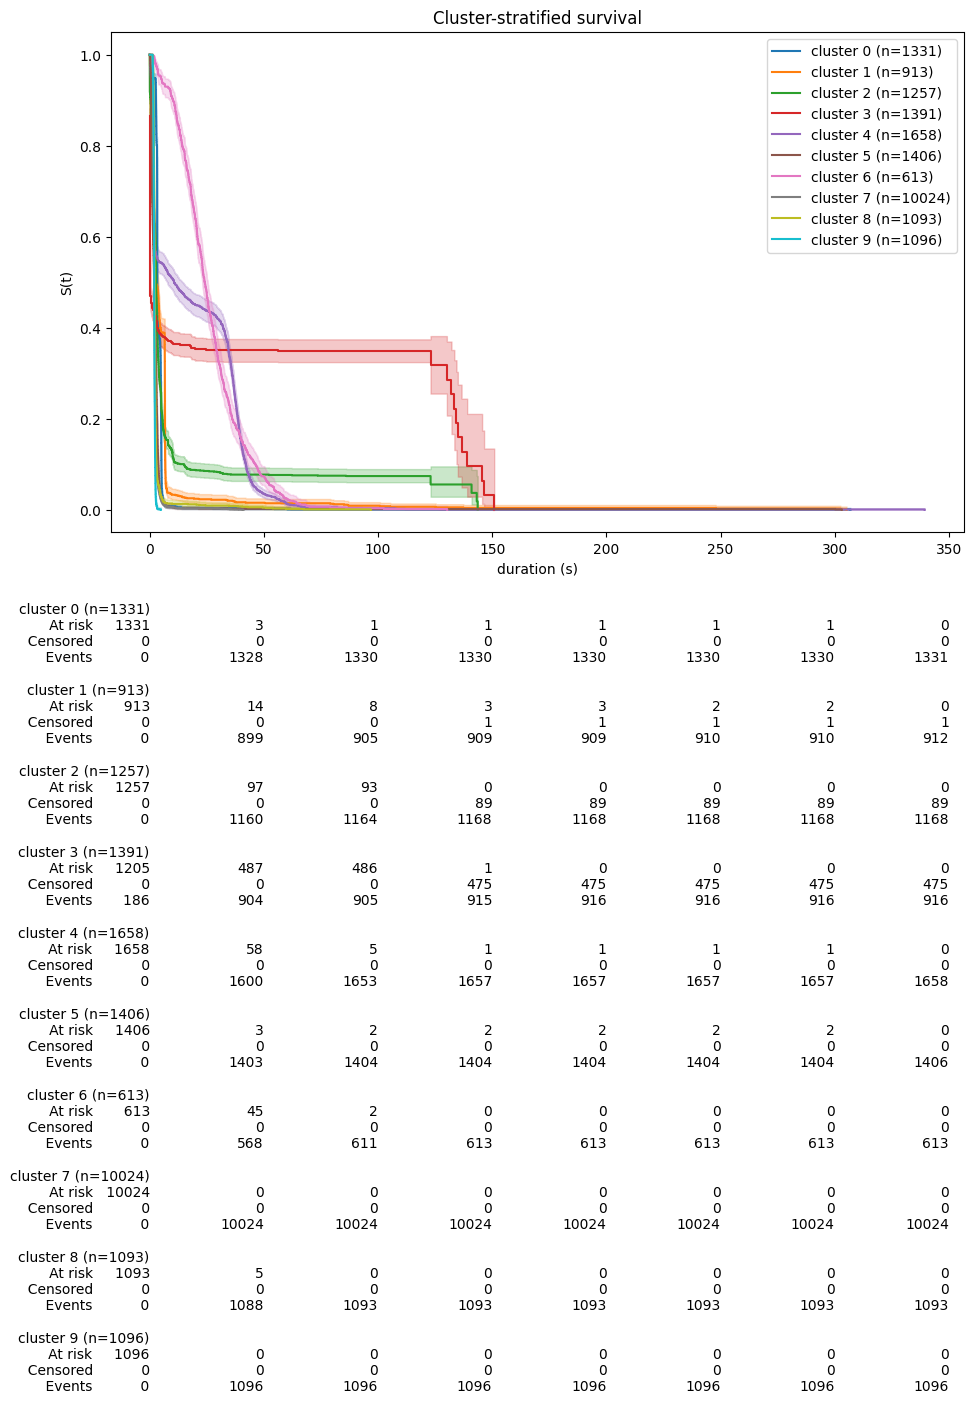

In [3]:
fig, ax = plt.subplots(figsize=(11, 6.5))
fitters = []
for c in sorted(clustered["cluster"].unique()):
    subset = clustered[clustered["cluster"] == c]
    kmf = KaplanMeierFitter().fit(
        subset["duration_sec"], subset["event_observed"], label=f"cluster {c} (n={len(subset)})"
    )
    kmf.plot_survival_function(ax=ax)
    fitters.append(kmf)

ax.set_xlabel("duration (s)")
ax.set_ylabel("S(t)")
ax.set_title("Cluster-stratified survival")
add_at_risk_counts(*fitters, ax=ax)
fig.tight_layout()
plt.show()

## 3. Log-rank test

One test across all nine clusters at once, plus the per-cluster numbers the test is summarizing, since a p-value alone does not say which clusters differ or by how much.

In [4]:
result = multivariate_logrank_test(
    clustered["duration_sec"], clustered["cluster"], clustered["event_observed"]
)
print(f"chi2 = {result.test_statistic:.1f}, p = {result.p_value:.2e}")

clustered.groupby("cluster").agg(
    n=("session", "count"),
    events=("event_observed", "sum"),
    event_rate=("event_observed", "mean"),
    median_duration_sec=("duration_sec", "median"),
    mean_duration_sec=("duration_sec", "mean"),
).round(3)

chi2 = 5583.8, p = 0.00e+00


,n,events,event_rate,median_duration_sec,mean_duration_sec
cluster,,,,,
0,1331,1331,1.000,3.272,4.120
1,913,912,0.999,2.706,5.873
2,1257,1168,0.929,2.812,12.151
3,1391,916,0.659,0.250,42.747
4,1658,1658,1.000,10.657,19.646
5,1406,1406,1.000,1.927,2.600
6,613,613,1.000,24.080,26.313
7,10024,10024,1.000,1.949,2.249
8,1093,1093,1.000,2.146,2.806


At n=20,782 a chi-square this large says nothing on its own; the p-value would come out this small for almost any partition of a dataset this size. What carries the finding is the spread in the table.

Cluster 3 is where the censoring lives: 1,391 sessions, 475 of them cut by the timeout, which is 83% of all 574 censored sessions. It is also the cluster with no client handshake at all, so these are connections opened and never taken through the SSH exchange. The 120s limit they run into is the authentication timeout rather than an idle one, which is why the cluster has a median duration of 0.25s and a mean of 42.7s: it mixes instant drops with connections held open until the honeypot gave up.

Cluster 6 sits at the other end, median 24s, every session attacker-terminated. Cluster 7, the largest, sits at 1.9s. A factor of twelve between medians is what makes stratifying worth doing; the p-value is not.

## 4. Nelson-Aalen cumulative hazard by cluster

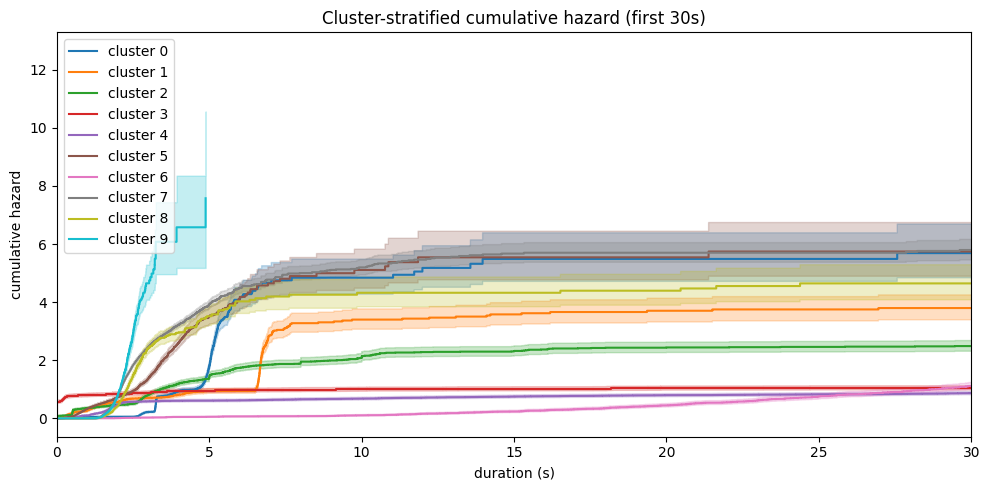

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for c in sorted(clustered["cluster"].unique()):
    subset = clustered[clustered["cluster"] == c]
    naf = NelsonAalenFitter().fit(
        subset["duration_sec"], subset["event_observed"], label=f"cluster {c}"
    )
    naf.plot_cumulative_hazard(ax=ax)

ax.set_xlabel("duration (s)")
ax.set_ylabel("cumulative hazard")
ax.set_xlim(0, 30)
ax.set_title("Cluster-stratified cumulative hazard (first 30s)")
fig.tight_layout()
plt.show()

## 5. Command count as the time axis

Same censoring flag, different clock: how many commands a session gets through before it ends, with a timed-out session still counted as censored rather than finished.

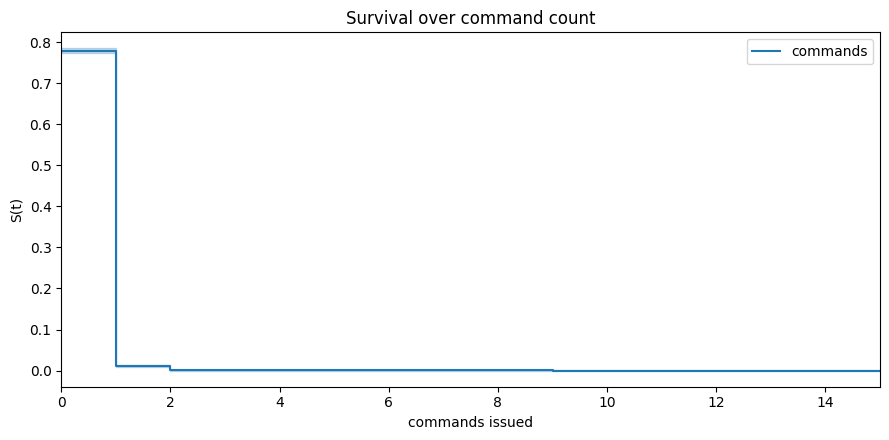

In [6]:
kmf_cmd = KaplanMeierFitter().fit(
    sessions["command_count"], sessions["event_observed"], label="commands"
)

fig, ax = plt.subplots(figsize=(9, 4.5))
kmf_cmd.plot_survival_function(ax=ax)
ax.set_xlabel("commands issued")
ax.set_ylabel("S(t)")
ax.set_xlim(0, 15)
ax.set_title("Survival over command count")
fig.tight_layout()
plt.show()

The cliff is at the first command. 78% of sessions get past zero commands and 1.1% get past one. Almost every session that types anything types exactly one command and stops, matching the bulk cluster's profile from 02. A payload that needed a multi-command sequence to land would show up as a second, later cliff, and there is not one here.

## 6. Cox PH on cluster

The log-rank test says the clusters differ; this quantifies each one against the biggest cluster as reference, so the effect sizes from section 3 get a hazard ratio to go with them.

In [7]:
reference = clustered["cluster"].value_counts().idxmax()

cph_df = clustered[["duration_sec", "event_observed"]].copy()
dummies = pd.get_dummies(clustered["cluster"].astype(str), prefix="cluster")
dummies = dummies.drop(columns=[f"cluster_{reference}"])
cph_df = pd.concat([cph_df, dummies], axis=1)

cph = CoxPHFitter().fit(cph_df, duration_col="duration_sec", event_col="event_observed")
print(f"reference: cluster {reference}")
cph.summary[["coef", "exp(coef)", "p"]].round(4)

reference: cluster 7


,coef,exp(coef),p
covariate,,,
cluster_0,-1.0054,0.3659,0.0
cluster_1,-0.8573,0.4243,0.0
cluster_2,-1.0136,0.3629,0.0
cluster_3,-1.8552,0.1564,0.0
cluster_4,-1.4837,0.2268,0.0
cluster_5,-0.1983,0.8202,0.0
cluster_6,-1.8700,0.1541,0.0
cluster_8,-0.2392,0.7873,0.0
cluster_9,0.1923,1.2121,0.0


Negative coefficients mean lower hazard, i.e. longer survival, relative to the reference cluster. Clusters 6 and 3 are the extremes at exp(coef) 0.154 and 0.156, one because its sessions genuinely run for tens of seconds and the other because a third of it is held open until the timeout fires. Cluster 9 is the only one above the reference at 1.21, ending marginally faster than the bulk. Every coefficient matches the direction of its median in section 3; the Cox model is confirming the KM story rather than adding a new one, which is the point of running it after the log-rank test rather than instead of it.